In [39]:
import sys
sys.path.insert(0, '..')
from dependencies import *


envelopes_log = eelbrain.load.unpickle(PROCESSED_PREDICTOR_DIR / f'~processed_envelopes-log.pickle')
subject_model_predictors = eelbrain.load.unpickle(PREDICTOR_DIR / f'~concatenated_predictors.pickle')
durations = get_durations(envelopes_log)
models = get_models()

In [40]:
# Loop over all models
for model in models:
    print(f'\nProcessing universal TRF for model: {model}')
    trf_list = []

    # Collect TRFs for all subjects for this model
    for subject in SUBJECTS:
        trf = eelbrain.load.unpickle(TRF_DIR / subject / f'{subject} {model}.pickle').h_scaled
        trf_list.append(trf[0])

    # Combine and average across subjects
    universal_trf = eelbrain.combine(trf_list).mean('case')

    # Save universal TRF for this model
    eelbrain.save.pickle(universal_trf, TRF_DIR / f'universal-trf-{model}.pickle')

    print(f'Saved universal TRF for model {model}')


Processing universal TRF for model: envelope_log
Saved universal TRF for model envelope_log

Processing universal TRF for model: envelope_onset
Saved universal TRF for model envelope_onset


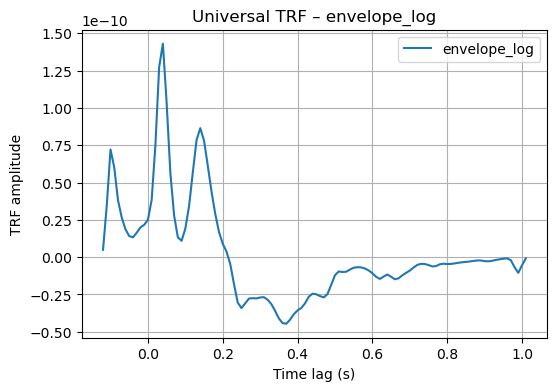

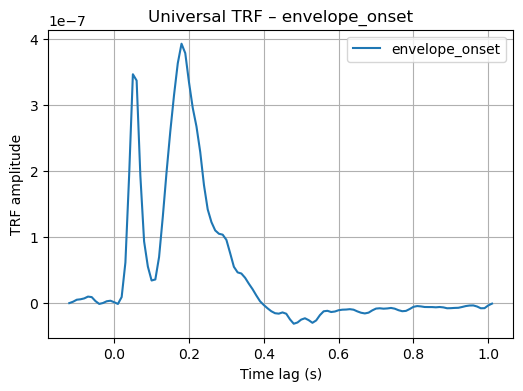

In [41]:
for model in models:
    # Load the universal TRF
    trf = eelbrain.load.unpickle(TRF_DIR / f'universal-trf-{model}.pickle')

    # h_scaled is sensor × time × predictors
    # Average across sensors
    trf_mean = trf.mean('sensor')

    # If you have multiple predictors (like 8-band), you can also average across predictors:
    if 'predictor' in trf_mean.dims:
        trf_mean = trf_mean.mean('predictor')

    # Plot the TRF as a function of time
    plt.figure(figsize=(6,4))
    plt.plot(trf_mean.time, trf_mean.x, label=f'{model}')
    plt.xlabel('Time lag (s)')
    plt.ylabel('TRF amplitude')
    plt.title(f'Universal TRF – {model}')
    plt.grid(True)
    plt.legend()
    plt.show()

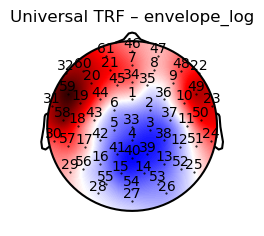

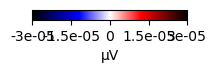

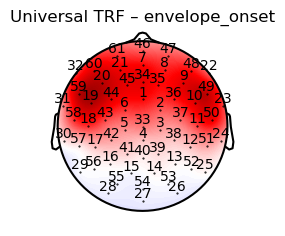

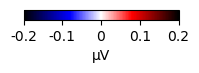

In [42]:
# Plot the TRFs
# Define your models and load universal TRFs

for model in models:

    trf = eelbrain.load.unpickle(TRF_DIR / f'universal-trf-{model}.pickle')

    title = f'Universal TRF – {model}'

    p = eelbrain.plot.Topomap(
        trf,
        sensorlabels='name',
        clip='circle',
        axtitle=title
    )

    p_cb = p.plot_colorbar(width=.1, w=2)


In [61]:
subject = 'S14'
eeg = eelbrain.load.unpickle(STIMULUS_DIR / f'{subject}concatenated_eeg.pickle')
montage = mne.channels.make_standard_montage('standard_1020')
names = montage.ch_names[:61]
eeg.sensor.names = names

# Load TRF
trf = eelbrain.load.unpickle(TRF_DIR / 'universal-trf-envelope_log.pickle')

# Your peak latencies (seconds)
peaks = [0.050, 0.150, 0.380]
peaks = np.arange(0.000, 0.500, 0.010)

# Get sensor names
sensor_names = eeg.sensor.names

for peak in peaks:

    # Extract TRF amplitude at the peak latency
    trf_peak = trf.sub(time=peak)

    values = trf_peak.x

    # Sort sensors by absolute amplitude
    order = np.argsort(np.abs(values))[::-1]

    print(f"\nPeak at {peak*1000:.0f} ms")
    print("Rank | Sensor | Amplitude")

    for rank, idx in enumerate(order[:5], start=1):
        print(f"{rank:>4} | {sensor_names[idx]:>6} | {trf.sensor.names[idx]:>6} | {values[idx]: .15f}")


Peak at 0 ms
Rank | Sensor | Amplitude
   1 |     Fz |     20 |  0.000000000075217
   2 |    TP9 |     49 |  0.000000000068473
   3 |    T10 |     48 |  0.000000000056796
   4 |    AF2 |     10 |  0.000000000055379
   5 |     C2 |     44 |  0.000000000051808

Peak at 10 ms
Rank | Sensor | Amplitude
   1 |    TP9 |     49 |  0.000000000084403
   2 |    AF2 |     10 |  0.000000000084210
   3 |    T10 |     48 |  0.000000000083011
   4 |     Fz |     20 |  0.000000000079476
   5 |   TP10 |     59 |  0.000000000076853

Peak at 20 ms
Rank | Sensor | Amplitude
   1 |     F1 |     19 |  0.000000000174650
   2 |   TP10 |     59 |  0.000000000173525
   3 |     Fz |     20 |  0.000000000152247
   4 |    AF1 |      8 |  0.000000000152102
   5 |    AFz |      9 |  0.000000000147635

Peak at 30 ms
Rank | Sensor | Amplitude
   1 |     F1 |     19 |  0.000000000331479
   2 |    FC4 |     34 |  0.000000000297560
   3 |     Fz |     20 |  0.000000000294658
   4 |   TP10 |     59 |  0.000000000285157
 

In [56]:
montage = mne.channels.make_standard_montage('standard_1020')
names = montage.ch_names[:61]
eeg.sensor.names = names

print(montage.ch_names)
print(len(eeg.sensor))
print(eeg.sensor.names)


['Fp1', 'Fpz', 'Fp2', 'AF9', 'AF7', 'AF5', 'AF3', 'AF1', 'AFz', 'AF2', 'AF4', 'AF6', 'AF8', 'AF10', 'F9', 'F7', 'F5', 'F3', 'F1', 'Fz', 'F2', 'F4', 'F6', 'F8', 'F10', 'FT9', 'FT7', 'FC5', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'FC6', 'FT8', 'FT10', 'T9', 'T7', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'T8', 'T10', 'TP9', 'TP7', 'CP5', 'CP3', 'CP1', 'CPz', 'CP2', 'CP4', 'CP6', 'TP8', 'TP10', 'P9', 'P7', 'P5', 'P3', 'P1', 'Pz', 'P2', 'P4', 'P6', 'P8', 'P10', 'PO9', 'PO7', 'PO5', 'PO3', 'PO1', 'POz', 'PO2', 'PO4', 'PO6', 'PO8', 'PO10', 'O1', 'Oz', 'O2', 'O9', 'Iz', 'O10', 'T3', 'T5', 'T4', 'T6', 'M1', 'M2', 'A1', 'A2']
61
['Fp1', 'Fpz', 'Fp2', 'AF9', 'AF7', 'AF5', 'AF3', 'AF1', 'AFz', 'AF2', 'AF4', 'AF6', 'AF8', 'AF10', 'F9', 'F7', 'F5', 'F3', 'F1', 'Fz', 'F2', 'F4', 'F6', 'F8', 'F10', 'FT9', 'FT7', 'FC5', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'FC6', 'FT8', 'FT10', 'T9', 'T7', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'T8', 'T10', 'TP9', 'TP7', 'CP5', 'CP3', 'CP1', 'CPz', 'CP2', 'CP4', 'CP6', 'T

# Deprecated code

In [19]:
# AVERAGE OF ALL TRFS

model = 'envelope_log'
trf_list = []

'''
max_subject = None
max_n = 0
for subject in SUBJECTS:
    boost_result = eelbrain.load.unpickle(TRF_DIR / subject / f'{subject} {model}.pickle')
    trf = boost_result.h_scaled
    n = len(boost_result.h_scaled.sensor)

    if n > max_n:
        max_n = n
        max_subject = subject

ref_boost_result = eelbrain.load.unpickle(TRF_DIR / max_subject / f'{max_subject} {model}.pickle')
ref_sensors = ref_boost_result.h_scaled.sensor
'''

for subject in SUBJECTS:
    trf = eelbrain.load.unpickle(TRF_DIR / subject / f'{subject} {model}.pickle').h_scaled
    print(trf)
    #trf_interpolated = trf.interpolate(sensor=ref_sensors)
    trf_list.append(trf)

universal_trf = eelbrain.combine(trf_list).mean('case')
eelbrain.save.pickle(universal_trf, TRF_DIR / 'universal-trf-average.pickle')
#universal_trf = sum(trf_list) / len(trf_list)

<NDVar 'envelope_onset': 61 sensor, 114 time>
<NDVar 'envelope_onset': 61 sensor, 114 time>
<NDVar 'envelope_onset': 61 sensor, 114 time>
<NDVar 'envelope_onset': 61 sensor, 114 time>
<NDVar 'envelope_onset': 61 sensor, 114 time>
<NDVar 'envelope_onset': 61 sensor, 114 time>
<NDVar 'envelope_onset': 61 sensor, 114 time>
<NDVar 'envelope_onset': 61 sensor, 114 time>
<NDVar 'envelope_onset': 61 sensor, 114 time>
<NDVar 'envelope_onset': 61 sensor, 114 time>
<NDVar 'envelope_onset': 61 sensor, 114 time>
<NDVar 'envelope_onset': 61 sensor, 114 time>
<NDVar 'envelope_onset': 61 sensor, 114 time>
<NDVar 'envelope_onset': 61 sensor, 114 time>
<NDVar 'envelope_onset': 61 sensor, 114 time>
<NDVar 'envelope_onset': 61 sensor, 114 time>
<NDVar 'envelope_onset': 61 sensor, 114 time>
<NDVar 'envelope_onset': 61 sensor, 114 time>
<NDVar 'envelope_onset': 61 sensor, 114 time>
<NDVar 'envelope_onset': 61 sensor, 114 time>
<NDVar 'envelope_onset': 61 sensor, 114 time>
<NDVar 'envelope_onset': 61 sensor